In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import shap

!wget 'https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data'
data = pd.read_csv('/content/parkinsons.data')

--2025-08-19 16:32:55--  https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40697 (40K) [application/x-www-form-urlencoded]
Saving to: ‘parkinsons.data.9’

parkinsons.data.9   100%[===================>]  39.74K  --.-KB/s    in 0.1s    

2025-08-19 16:32:56 (320 KB/s) - ‘parkinsons.data.9’ saved [40697/40697]



In [ ]:
print(data.head())

             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
X = data.drop(['name', 'status'], axis=1)
y = data['status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=True)

[0]	validation_0-logloss:0.53164
[1]	validation_0-logloss:0.50123
[2]	validation_0-logloss:0.47229
[3]	validation_0-logloss:0.44955
[4]	validation_0-logloss:0.43142
[5]	validation_0-logloss:0.41324
[6]	validation_0-logloss:0.38960
[7]	validation_0-logloss:0.36790
[8]	validation_0-logloss:0.35416
[9]	validation_0-logloss:0.34840
[10]	validation_0-logloss:0.33154
[11]	validation_0-logloss:0.31922
[12]	validation_0-logloss:0.30374
[13]	validation_0-logloss:0.29539
[14]	validation_0-logloss:0.29209
[15]	validation_0-logloss:0.28886
[16]	validation_0-logloss:0.28395
[17]	validation_0-logloss:0.27313
[18]	validation_0-logloss:0.27538
[19]	validation_0-logloss:0.27189
[20]	validation_0-logloss:0.25847
[21]	validation_0-logloss:0.24678
[22]	validation_0-logloss:0.24750
[23]	validation_0-logloss:0.24324
[24]	validation_0-logloss:0.23979
[25]	validation_0-logloss:0.23605
[26]	validation_0-logloss:0.23329
[27]	validation_0-logloss:0.22895
[28]	validation_0-logloss:0.22762
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.93      0.86      0.89        29

    accuracy                           0.85        39
   macro avg       0.80      0.83      0.81        39
weighted avg       0.86      0.85      0.85        39


Confusion Matrix:
[[ 8  2]
 [ 4 25]]



Важность признаков:
             Признак  Важность
7         Jitter:DDP  0.422692
21               PPE  0.107470
18           spread1  0.075506
14               NHR  0.050609
11      Shimmer:APQ5  0.043891
12          MDVP:APQ  0.033513
17               DFA  0.031152
0        MDVP:Fo(Hz)  0.029570
20                D2  0.029498
19           spread2  0.025130
1       MDVP:Fhi(Hz)  0.022036
15               HNR  0.021679
16              RPDE  0.019475
5           MDVP:RAP  0.018459
2       MDVP:Flo(Hz)  0.018409
3     MDVP:Jitter(%)  0.016170
10      Shimmer:APQ3  0.013021
4   MDVP:Jitter(Abs)  0.008509
9   MDVP:Shimmer(dB)  0.006888
13       Shimmer:DDA  0.004213
6           MDVP:PPQ  0.002110
8       MDVP:Shimmer  0.000000


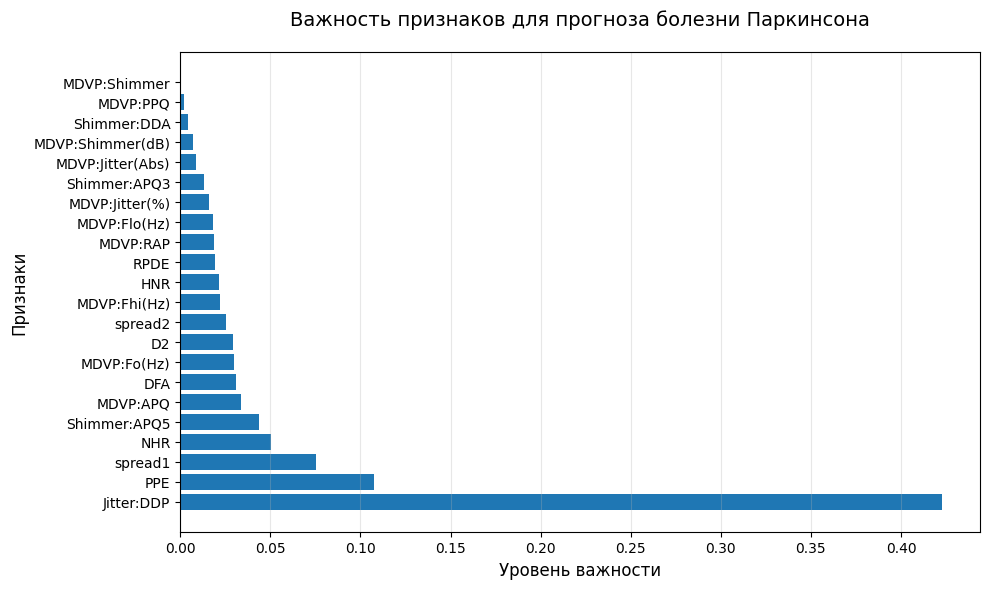

In [ ]:
importance = model.feature_importances_


feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': importance
}).sort_values('Важность', ascending=False)

print("\nВажность признаков:")
print(feature_importance)



plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'])
plt.xlabel('Уровень важности', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков для прогноза болезни Паркинсона', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

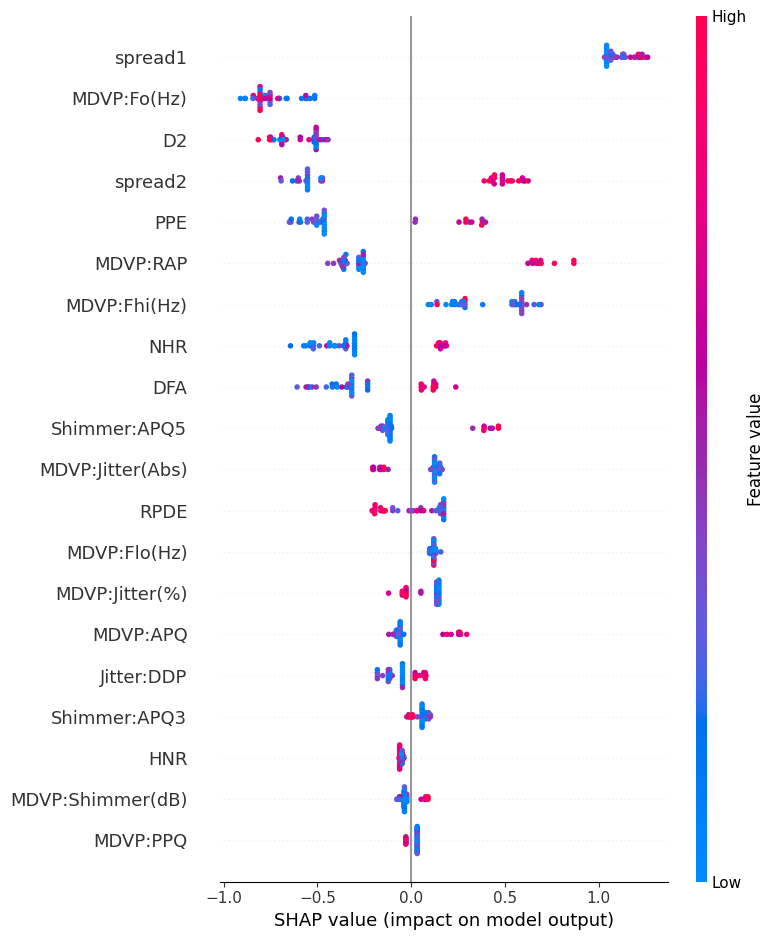

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_scaled[0,:], feature_names=X.columns)